DATASET LOADED
File: /content/Merged_Stock_Market_Dataset.csv
Rows : 177728
Columns: 10

Columns:
['Date', 'Ticker', 'Company', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Source']

DATA PREPROCESSING
Duplicate rows removed: 0
Final rows after preprocessing: 177728
Number of unique tickers: 70

Missing values:
Date         0
Ticker       0
Company      0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

FEATURE ENGINEERING
Creating next trading-day target...
Number of features: 60

MODEL DATA
Rows: 173960
Features: 60
Tickers: 70
Date range: 2002-10-18 to 2026-09-16

TRAIN / TEST SPLIT
Training period: 2002-10-18 to 2022-04-06
Testing period : 2022-04-07 to 2026-09-16
Training rows: 96419
Testing rows : 77541

TRAINING XGBOOST MODEL
XGBoost model trained successfully.

XGBOOST MODEL PERFORMANCE
MAE  : 200.349101
MSE  : 1479786.608832
RMSE : 1216.464800
R²   : 0.974191
MAPE : 2.5491%

ACTUAL VS PREDICTED VALUES


,Date,Target_Date,Ticker,Company,Close,Actual_Next_Close,Predicted_Next_Close,Absolute_Error,Actual_Direction,Predicted_Direction
96419,2022-04-07,2022-04-08,6758.T,6758.T,2409.000000,2439.000000,2404.017822,34.982178,UP,DOWN
96420,2022-04-07,2022-04-08,6861.T,6861.T,57120.000000,57760.000000,66853.257812,9093.257812,UP,UP
96421,2022-04-07,2022-04-08,7203.T,7203.T,2168.500000,2095.500000,2136.914062,41.414062,DOWN,DOWN
96422,2022-04-07,2022-04-08,9984.T,9984.T,1413.500000,1420.750000,1402.351318,18.398682,UP,DOWN
96423,2022-04-07,2022-04-08,AAPL,AAPL,172.139999,170.089996,170.951843,0.861847,DOWN,DOWN
96424,2022-04-07,2022-04-08,ADANIENT.NS,Adani_Enterprises,2099.050049,2170.949951,2084.651123,86.298828,UP,DOWN
96425,2022-04-07,2022-04-08,ADANIPORTS.NS,Adani_Ports,817.400024,839.299988,820.126953,19.173035,UP,UP
96426,2022-04-07,2022-04-08,ADBE,ADBE,452.720001,445.339996,454.772827,9.432831,DOWN,UP
96427,2022-04-07,2022-04-08,AMD,AMD,103.720001,101.000000,103.324097,2.324097,DOWN,DOWN
96428,2022-04-07,2022-04-08,AMZN,AMZN,157.784500,154.460495,156.477966,2.017471,DOWN,DOWN



DIRECTIONAL PERFORMANCE
Next-day direction accuracy: 50.37%

TOP 20 IMPORTANT FEATURES


,Feature,Importance
40,EMA_10,0.604718
32,MA_10,0.102287
54,BB_Upper,0.061146
17,Close_Lag_10,0.058291
2,Low,0.020549
55,BB_Lower,0.018343
12,Close_Lag_1,0.017164
16,Close_Lag_7,0.015008
3,Close,0.014429
39,EMA_5,0.013845


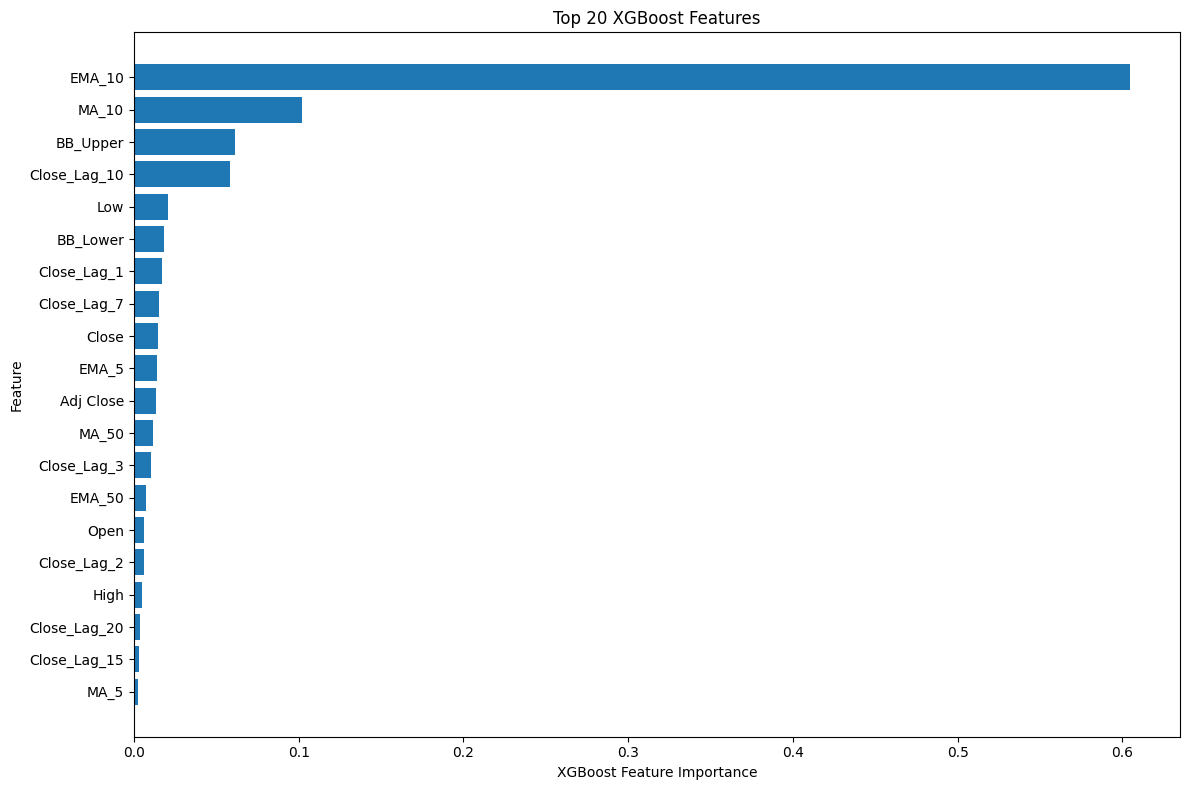

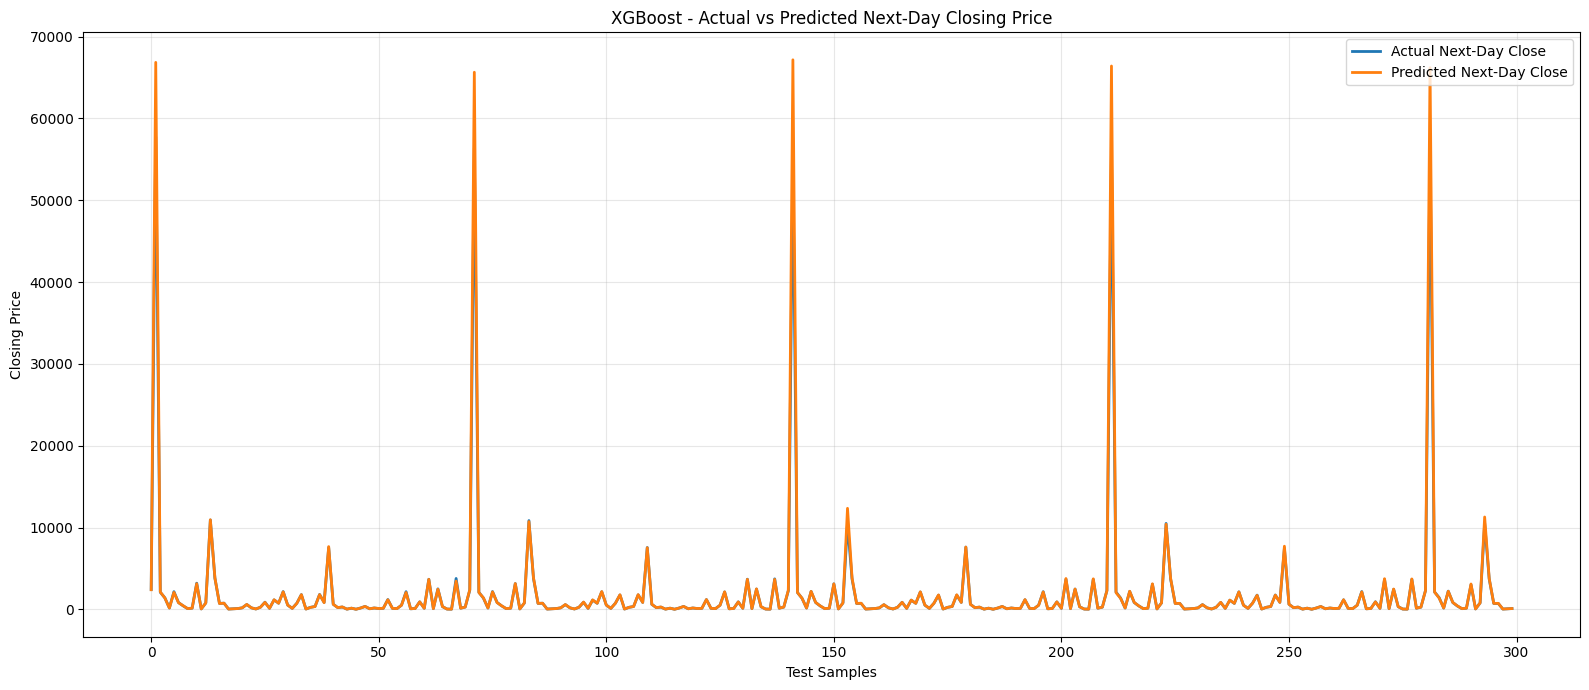

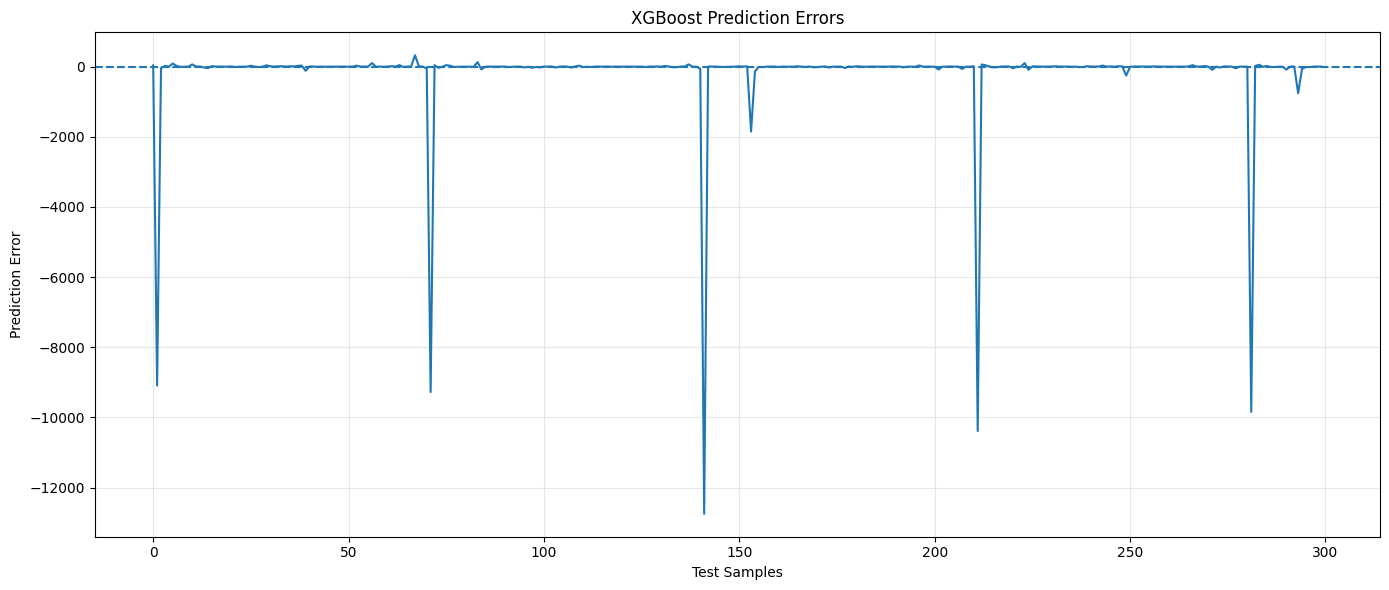

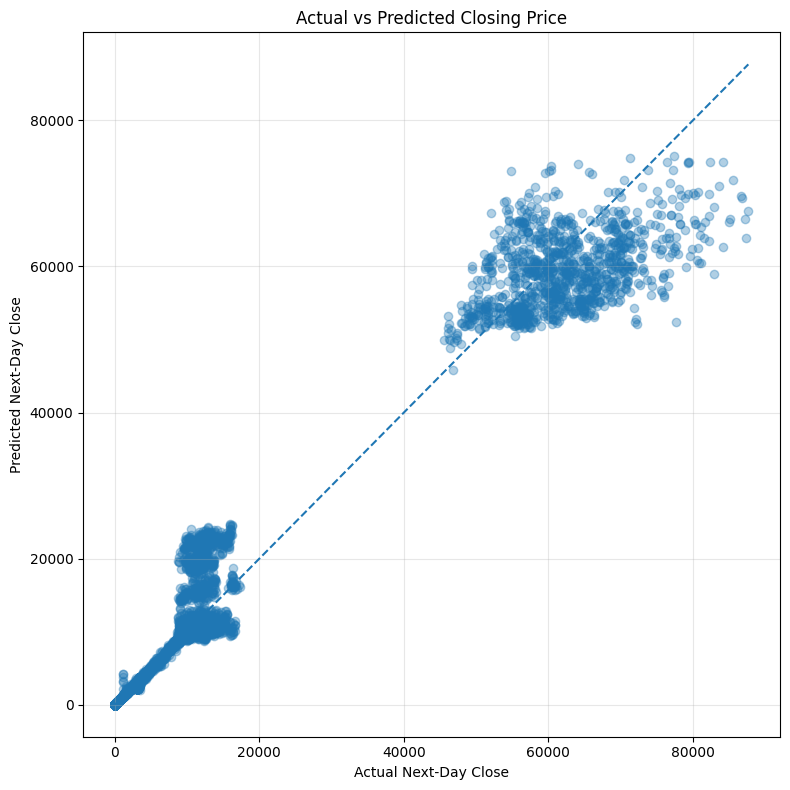


PREDICTION FILE SAVED
/content/XGBoost_Stock_Predictions.csv

NEXT-DAY STOCK PRICE PREDICTION
Enter a ticker from the dataset.
Example tickers:
['6758.T', '6861.T', '7203.T', '9984.T', 'AAPL', 'ADANIENT.NS', 'ADANIPORTS.NS', 'ADBE', 'AMD', 'AMZN', 'ASIANPAINT.NS', 'AVGO', 'AXISBANK.NS', 'AZN.L', 'BAJAJ-AUTO.NS']

Enter Company/Ticker for next-day prediction: 6758.T

NEXT-DAY PREDICTION RESULT


,Ticker,Company,Latest_Date,Open,High,Low,Current_Close,Adj_Close,Volume,Predicted_Next_Close,Predicted_Change,Predicted_Change_Percent,Predicted_Direction
0,6758.T,6758.T,2026-09-17,3721.0,3758.0,3707.0,3752.0,3752.0,5887600.0,3682.950928,-69.049072,-1.840327,DOWN



Current Close        : 3752.0000
Predicted Next Close : 3682.9509
Expected Change      : -1.84%
Predicted Direction   : DOWN

PROJECT COMPLETED SUCCESSFULLY
Original dataset rows       : 177,728
Number of tickers           : 70
Number of model features    : 60
Training rows               : 96,419
Testing rows                : 77,541

MAE                         : 200.349101
MSE                         : 1479786.608832
RMSE                        : 1216.464800
R²                          : 0.974191
MAPE                        : 2.5491%
Direction Accuracy          : 50.37%

Prediction CSV:
/content/XGBoost_Stock_Predictions.csv


In [3]:
# ================================================================
# XGBOOST STOCK MARKET NEXT-DAY CLOSE PRICE PREDICTION
# COMPLETE END-TO-END PROJECT - SINGLE GOOGLE COLAB CELL
# ================================================================
#
# Dataset:
# Merged_Stock_Market_Dataset(1).csv
#
# Target:
# Next trading day's Close price for each Ticker
#
# Model:
# XGBoost Regressor
#
# ================================================================

# ================================================================
# 1. INSTALL REQUIRED LIBRARIES
# ================================================================

!pip -q install xgboost openpyxl

# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ================================================================
# 3. LOAD DATASET
# ================================================================

# If you upload the CSV directly into Colab, this path will work.
# Otherwise change the path to your uploaded CSV location.

FILE_PATH = "/content/Merged_Stock_Market_Dataset.csv"

# Automatic fallback for the common Colab upload name
if not os.path.exists(FILE_PATH):
    possible_files = [
        "/content/Merged_Stock_Market_Dataset.csv",
        "/content/Stock_market_marged_dataset.csv"
    ]

    found_file = None

    for file in possible_files:
        if os.path.exists(file):
            found_file = file
            break

    if found_file is not None:
        FILE_PATH = found_file

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        "Dataset not found. Please upload the CSV file to Google Colab."
    )

df = pd.read_csv(FILE_PATH)

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)
print("File:", FILE_PATH)
print("Rows :", df.shape[0])
print("Columns:", df.shape[1])
print()

print("Columns:")
print(df.columns.tolist())
print()

# ================================================================
# 4. STANDARDIZE COLUMN NAMES
# ================================================================

df.columns = df.columns.str.strip()

required_columns = [
    "Date",
    "Ticker",
    "Company",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# ================================================================
# 5. DATA PREPROCESSING
# ================================================================

print("=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Convert date
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Remove rows with invalid dates
df = df.dropna(
    subset=["Date", "Ticker"]
).copy()

# Remove duplicate Ticker + Date records
before_duplicates = len(df)

df = df.drop_duplicates(
    subset=["Ticker", "Date"],
    keep="last"
).copy()

after_duplicates = len(df)

print(
    "Duplicate rows removed:",
    before_duplicates - after_duplicates
)

# Sort chronologically within each ticker
df = df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

# Convert numerical columns
numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Replace infinite values
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Treat zero volume as missing
df["Volume"] = df["Volume"].replace(
    0,
    np.nan
)

# Forward/backward fill volume within each ticker
df["Volume"] = (
    df.groupby("Ticker")["Volume"]
      .transform(lambda x: x.ffill().bfill())
)

# Remove rows where essential market values are unavailable
df = df.dropna(
    subset=[
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close",
        "Volume"
    ]
).reset_index(drop=True)

print("Final rows after preprocessing:", len(df))
print("Number of unique tickers:", df["Ticker"].nunique())

print()
print("Missing values:")
print(df[required_columns].isna().sum())

# ================================================================
# 6. FEATURE ENGINEERING
# ================================================================

print()
print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# ------------------------------------------------
# Basic price relationships
# ------------------------------------------------

df["Daily_Return"] = (
    df.groupby("Ticker")["Close"]
      .pct_change()
)

df["Price_Change"] = (
    df.groupby("Ticker")["Close"]
      .diff()
)

df["High_Low_Range"] = (
    df["High"] - df["Low"]
)

df["Open_Close_Range"] = (
    df["Close"] - df["Open"]
)

df["High_Low_Pct"] = (
    (df["High"] - df["Low"])
    / df["Close"].replace(0, np.nan)
)

df["Open_Close_Pct"] = (
    (df["Close"] - df["Open"])
    / df["Open"].replace(0, np.nan)
)

# ------------------------------------------------
# Lag features
# ------------------------------------------------

lag_periods = [
    1,
    2,
    3,
    5,
    7,
    10,
    15,
    20
]

for lag in lag_periods:

    df[f"Close_Lag_{lag}"] = (
        df.groupby("Ticker")["Close"]
          .shift(lag)
    )

    df[f"Volume_Lag_{lag}"] = (
        df.groupby("Ticker")["Volume"]
          .shift(lag)
    )

# ------------------------------------------------
# Return lag features
# ------------------------------------------------

for lag in [1, 2, 3, 5, 10]:

    df[f"Return_Lag_{lag}"] = (
        df.groupby("Ticker")["Daily_Return"]
          .shift(lag)
    )

# ------------------------------------------------
# Moving averages
# ------------------------------------------------

moving_windows = [
    5,
    10,
    20,
    50
]

for window in moving_windows:

    df[f"MA_{window}"] = (
        df.groupby("Ticker")["Close"]
          .transform(
              lambda x: x.rolling(
                  window,
                  min_periods=window
              ).mean()
          )
    )

    df[f"Volume_MA_{window}"] = (
        df.groupby("Ticker")["Volume"]
          .transform(
              lambda x: x.rolling(
                  window,
                  min_periods=window
              ).mean()
          )
    )

# ------------------------------------------------
# Exponential moving averages
# ------------------------------------------------

for span in [5, 10, 20, 50]:

    df[f"EMA_{span}"] = (
        df.groupby("Ticker")["Close"]
          .transform(
              lambda x: x.ewm(
                  span=span,
                  adjust=False
              ).mean()
          )
    )

# ------------------------------------------------
# Volatility
# ------------------------------------------------

for window in [5, 10, 20]:

    df[f"Volatility_{window}"] = (
        df.groupby("Ticker")["Daily_Return"]
          .transform(
              lambda x: x.rolling(
                  window,
                  min_periods=window
              ).std()
          )
    )

# ------------------------------------------------
# Volume change
# ------------------------------------------------

df["Volume_Change"] = (
    df.groupby("Ticker")["Volume"]
      .pct_change()
)

df["Volume_Change_5D"] = (
    df.groupby("Ticker")["Volume"]
      .pct_change(5)
)

# ------------------------------------------------
# RSI - 14 period
# ------------------------------------------------

def calculate_rsi(series, period=14):

    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(
        alpha=1 / period,
        min_periods=period,
        adjust=False
    ).mean()

    avg_loss = loss.ewm(
        alpha=1 / period,
        min_periods=period,
        adjust=False
    ).mean()

    rs = avg_gain / avg_loss.replace(
        0,
        np.nan
    )

    rsi = 100 - (
        100 / (1 + rs)
    )

    return rsi

df["RSI_14"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: calculate_rsi(x, 14)
      )
)

# ------------------------------------------------
# MACD
# ------------------------------------------------

df["EMA_12"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.ewm(
              span=12,
              adjust=False
          ).mean()
      )
)

df["EMA_26"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.ewm(
              span=26,
              adjust=False
          ).mean()
      )
)

df["MACD"] = (
    df["EMA_12"] -
    df["EMA_26"]
)

df["MACD_Signal"] = (
    df.groupby("Ticker")["MACD"]
      .transform(
          lambda x: x.ewm(
              span=9,
              adjust=False
          ).mean()
      )
)

df["MACD_Histogram"] = (
    df["MACD"] -
    df["MACD_Signal"]
)

# ------------------------------------------------
# Bollinger Bands
# ------------------------------------------------

df["BB_Middle"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.rolling(
              20,
              min_periods=20
          ).mean()
      )
)

df["BB_STD"] = (
    df.groupby("Ticker")["Close"]
      .transform(
          lambda x: x.rolling(
              20,
              min_periods=20
          ).std()
      )
)

df["BB_Upper"] = (
    df["BB_Middle"] +
    2 * df["BB_STD"]
)

df["BB_Lower"] = (
    df["BB_Middle"] -
    2 * df["BB_STD"]
)

df["BB_Position"] = (
    (df["Close"] - df["BB_Lower"])
    /
    (
        df["BB_Upper"] -
        df["BB_Lower"]
    ).replace(0, np.nan)
)

# ------------------------------------------------
# Price relative to moving averages
# ------------------------------------------------

df["Close_to_MA5"] = (
    df["Close"] /
    df["MA_5"].replace(0, np.nan)
)

df["Close_to_MA20"] = (
    df["Close"] /
    df["MA_20"].replace(0, np.nan)
)

df["Close_to_MA50"] = (
    df["Close"] /
    df["MA_50"].replace(0, np.nan)
)

# ================================================================
# 7. CREATE NEXT-DAY TARGET
# ================================================================

print("Creating next trading-day target...")

df["Target_Next_Close"] = (
    df.groupby("Ticker")["Close"]
      .shift(-1)
)

# Target date
df["Target_Date"] = (
    df.groupby("Ticker")["Date"]
      .shift(-1)
)

# ================================================================
# 8. REMOVE INVALID FEATURE ROWS
# ================================================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

# ================================================================
# 9. DEFINE FEATURES
# ================================================================

features = [

    # Original OHLCV features
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",

    # Price relationships
    "Daily_Return",
    "Price_Change",
    "High_Low_Range",
    "Open_Close_Range",
    "High_Low_Pct",
    "Open_Close_Pct",

    # Close lag features
    "Close_Lag_1",
    "Close_Lag_2",
    "Close_Lag_3",
    "Close_Lag_5",
    "Close_Lag_7",
    "Close_Lag_10",
    "Close_Lag_15",
    "Close_Lag_20",

    # Volume lag features
    "Volume_Lag_1",
    "Volume_Lag_2",
    "Volume_Lag_3",
    "Volume_Lag_5",
    "Volume_Lag_7",
    "Volume_Lag_10",

    # Return lags
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Return_Lag_5",
    "Return_Lag_10",

    # Moving averages
    "MA_5",
    "MA_10",
    "MA_20",
    "MA_50",

    # Volume moving averages
    "Volume_MA_5",
    "Volume_MA_10",
    "Volume_MA_20",
    "Volume_MA_50",

    # Exponential moving averages
    "EMA_5",
    "EMA_10",
    "EMA_20",
    "EMA_50",

    # Volatility
    "Volatility_5",
    "Volatility_10",
    "Volatility_20",

    # Volume changes
    "Volume_Change",
    "Volume_Change_5D",

    # Technical indicators
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",

    # Bollinger Bands
    "BB_Middle",
    "BB_STD",
    "BB_Upper",
    "BB_Lower",
    "BB_Position",

    # Relative prices
    "Close_to_MA5",
    "Close_to_MA20",
    "Close_to_MA50"
]

# Make sure all features exist
features = [
    feature
    for feature in features
    if feature in df.columns
]

print("Number of features:", len(features))

# ================================================================
# 10. CREATE MODEL DATA
# ================================================================

model_df = df[
    [
        "Date",
        "Target_Date",
        "Ticker",
        "Company"
    ] +
    features +
    ["Target_Next_Close"]
].copy()

# Remove rows with missing feature/target values
model_df = model_df.dropna(
    subset=features + ["Target_Next_Close"]
).copy()

model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)

model_df = model_df.dropna(
    subset=features + ["Target_Next_Close"]
).copy()

# Sort chronologically
model_df = model_df.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

print()
print("=" * 80)
print("MODEL DATA")
print("=" * 80)
print("Rows:", len(model_df))
print("Features:", len(features))
print("Tickers:", model_df["Ticker"].nunique())
print(
    "Date range:",
    model_df["Date"].min().date(),
    "to",
    model_df["Date"].max().date()
)

# ================================================================
# 11. CHRONOLOGICAL TRAIN/TEST SPLIT
# ================================================================
#
# IMPORTANT:
# For stock time-series data we should NOT randomly shuffle rows.
#
# Training:
# Oldest 80%
#
# Testing:
# Latest 20%
#
# This prevents future information from entering training data.
# ================================================================

unique_dates = (
    model_df["Date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

split_date = unique_dates[
    int(len(unique_dates) * 0.80)
]

train_df = model_df[
    model_df["Date"] < split_date
].copy()

test_df = model_df[
    model_df["Date"] >= split_date
].copy()

X_train = train_df[features]
y_train = train_df["Target_Next_Close"]

X_test = test_df[features]
y_test = test_df["Target_Next_Close"]

print()
print("=" * 80)
print("TRAIN / TEST SPLIT")
print("=" * 80)

print(
    "Training period:",
    train_df["Date"].min().date(),
    "to",
    train_df["Date"].max().date()
)

print(
    "Testing period :",
    test_df["Date"].min().date(),
    "to",
    test_df["Date"].max().date()
)

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

# ================================================================
# 12. XGBOOST MODEL
# ================================================================

print()
print("=" * 80)
print("TRAINING XGBOOST MODEL")
print("=" * 80)

model = XGBRegressor(

    # Number of boosting trees
    n_estimators=800,

    # Learning rate
    learning_rate=0.03,

    # Maximum tree depth
    max_depth=8,

    # Minimum child weight
    min_child_weight=3,

    # Subsample rows
    subsample=0.85,

    # Subsample features
    colsample_bytree=0.85,

    # Regularization
    reg_alpha=0.05,
    reg_lambda=1.0,

    # Random seed
    random_state=42,

    # Tree method
    tree_method="hist",

    # Parallel processing
    n_jobs=-1,

    # Objective
    objective="reg:squarederror",

    # Evaluation metric
    eval_metric="rmse"
)

# Train
model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=False
)

print("XGBoost model trained successfully.")

# ================================================================
# 13. GENERATE TEST PREDICTIONS
# ================================================================

y_pred = model.predict(
    X_test
)

# ================================================================
# 14. MODEL EVALUATION
# ================================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

# Mean Absolute Percentage Error
non_zero_actual = y_test != 0

mape = (
    np.mean(
        np.abs(
            (
                y_test[non_zero_actual].values -
                y_pred[non_zero_actual]
            )
            /
            y_test[non_zero_actual].values
        )
    )
    * 100
)

# ================================================================
# 15. PRINT MODEL PERFORMANCE
# ================================================================

print()
print("=" * 80)
print("XGBOOST MODEL PERFORMANCE")
print("=" * 80)

print(f"MAE  : {mae:.6f}")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")
print(f"MAPE : {mape:.4f}%")

# ================================================================
# 16. ACTUAL VS PREDICTED RESULT TABLE
# ================================================================

results = test_df[
    [
        "Date",
        "Target_Date",
        "Ticker",
        "Company",
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close",
        "Volume"
    ]
].copy()

results["Actual_Next_Close"] = y_test.values

results["Predicted_Next_Close"] = y_pred

results["Error"] = (
    results["Actual_Next_Close"] -
    results["Predicted_Next_Close"]
)

results["Absolute_Error"] = (
    results["Error"].abs()
)

results["Percentage_Error"] = (
    results["Absolute_Error"]
    /
    results["Actual_Next_Close"].replace(
        0,
        np.nan
    )
    * 100
)

# Direction
results["Actual_Direction"] = np.where(
    results["Actual_Next_Close"] >= results["Close"],
    "UP",
    "DOWN"
)

results["Predicted_Direction"] = np.where(
    results["Predicted_Next_Close"] >= results["Close"],
    "UP",
    "DOWN"
)

results["Direction_Correct"] = (
    results["Actual_Direction"] ==
    results["Predicted_Direction"]
)

# ================================================================
# 17. DISPLAY SAMPLE PREDICTIONS
# ================================================================

print()
print("=" * 80)
print("ACTUAL VS PREDICTED VALUES")
print("=" * 80)

display(
    results[
        [
            "Date",
            "Target_Date",
            "Ticker",
            "Company",
            "Close",
            "Actual_Next_Close",
            "Predicted_Next_Close",
            "Absolute_Error",
            "Actual_Direction",
            "Predicted_Direction"
        ]
    ].head(25)
)

# ================================================================
# 18. DIRECTIONAL ACCURACY
# ================================================================

direction_accuracy = (
    results["Direction_Correct"].mean()
    * 100
)

print()
print("=" * 80)
print("DIRECTIONAL PERFORMANCE")
print("=" * 80)

print(
    f"Next-day direction accuracy: "
    f"{direction_accuracy:.2f}%"
)

# ================================================================
# 19. FEATURE IMPORTANCE
# ================================================================

importance_df = pd.DataFrame({

    "Feature": features,

    "Importance": model.feature_importances_

}).sort_values(
    "Importance",
    ascending=False
)

print()
print("=" * 80)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 80)

display(
    importance_df.head(20)
)

# ================================================================
# 20. FEATURE IMPORTANCE GRAPH
# ================================================================

plt.figure(
    figsize=(12, 8)
)

top_features = (
    importance_df
    .head(20)
    .sort_values("Importance")
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 XGBoost Features"
)

plt.tight_layout()

plt.show()

# ================================================================
# 21. ACTUAL VS PREDICTED GRAPH
# ================================================================

# Use the first 300 test observations for readable visualization
plot_n = min(
    300,
    len(results)
)

plt.figure(
    figsize=(16, 7)
)

plt.plot(
    results["Actual_Next_Close"].values[:plot_n],
    label="Actual Next-Day Close",
    linewidth=2
)

plt.plot(
    results["Predicted_Next_Close"].values[:plot_n],
    label="Predicted Next-Day Close",
    linewidth=2
)

plt.xlabel(
    "Test Samples"
)

plt.ylabel(
    "Closing Price"
)

plt.title(
    "XGBoost - Actual vs Predicted Next-Day Closing Price"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ================================================================
# 22. RESIDUAL / ERROR GRAPH
# ================================================================

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    results["Error"].values[:plot_n]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Test Samples"
)

plt.ylabel(
    "Prediction Error"
)

plt.title(
    "XGBoost Prediction Errors"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ================================================================
# 23. ACTUAL VS PREDICTED SCATTER PLOT
# ================================================================

plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    results["Actual_Next_Close"],
    results["Predicted_Next_Close"],
    alpha=0.35
)

minimum_value = min(
    results["Actual_Next_Close"].min(),
    results["Predicted_Next_Close"].min()
)

maximum_value = max(
    results["Actual_Next_Close"].max(),
    results["Predicted_Next_Close"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Next-Day Close"
)

plt.ylabel(
    "Predicted Next-Day Close"
)

plt.title(
    "Actual vs Predicted Closing Price"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ================================================================
# 24. EXPORT TEST PREDICTIONS
# ================================================================

prediction_file = (
    "/content/XGBoost_Stock_Predictions.csv"
)

results.to_csv(
    prediction_file,
    index=False
)

print()
print("=" * 80)
print("PREDICTION FILE SAVED")
print("=" * 80)

print(prediction_file)

# ================================================================
# 25. NEXT-DAY PREDICTION FUNCTION
# ================================================================
#
# This function uses the latest available historical data for a
# selected ticker and predicts its NEXT available trading-day close.
#
# Example:
# predict_next_day("6758.T")
#
# ================================================================

def predict_next_day(selected_ticker):

    ticker_data = df[
        df["Ticker"].astype(str).str.upper()
        ==
        str(selected_ticker).upper()
    ].copy()

    if ticker_data.empty:

        print(
            f"Ticker '{selected_ticker}' was not found."
        )

        print(
            "Available ticker examples:"
        )

        print(
            df["Ticker"]
            .drop_duplicates()
            .head(20)
            .tolist()
        )

        return None

    # Sort
    ticker_data = ticker_data.sort_values(
        "Date"
    ).copy()

    # Latest row
    latest = ticker_data.iloc[-1]

    # Make sure all model features exist
    missing = [
        col
        for col in features
        if col not in ticker_data.columns
    ]

    if missing:

        print(
            "Missing prediction features:",
            missing
        )

        return None

    latest_features = (
        ticker_data[features]
        .iloc[-1:]
        .copy()
    )

    # Clean values
    latest_features = latest_features.replace(
        [np.inf, -np.inf],
        np.nan
    )

    if latest_features.isna().any().any():

        print(
            "The latest row does not contain enough "
            "historical information for prediction."
        )

        print(
            "Missing features:"
        )

        print(
            latest_features.columns[
                latest_features.isna().any()
            ].tolist()
        )

        return None

    # Prediction
    prediction = model.predict(
        latest_features
    )[0]

    current_close = float(
        latest["Close"]
    )

    predicted_change = (
        prediction -
        current_close
    )

    predicted_change_pct = (
        predicted_change /
        current_close
        * 100
        if current_close != 0
        else np.nan
    )

    predicted_direction = (
        "UP"
        if prediction >= current_close
        else "DOWN"
    )

    prediction_result = pd.DataFrame({

        "Ticker": [
            latest["Ticker"]
        ],

        "Company": [
            latest["Company"]
        ],

        "Latest_Date": [
            latest["Date"]
        ],

        "Open": [
            latest["Open"]
        ],

        "High": [
            latest["High"]
        ],

        "Low": [
            latest["Low"]
        ],

        "Current_Close": [
            current_close
        ],

        "Adj_Close": [
            latest["Adj Close"]
        ],

        "Volume": [
            latest["Volume"]
        ],

        "Predicted_Next_Close": [
            prediction
        ],

        "Predicted_Change": [
            predicted_change
        ],

        "Predicted_Change_Percent": [
            predicted_change_pct
        ],

        "Predicted_Direction": [
            predicted_direction
        ]
    })

    return prediction_result


# ================================================================
# 26. INTERACTIVE NEXT-DAY PREDICTION
# ================================================================

print()
print("=" * 80)
print("NEXT-DAY STOCK PRICE PREDICTION")
print("=" * 80)

print(
    "Enter a ticker from the dataset."
)

print(
    "Example tickers:"
)

print(
    df["Ticker"]
    .drop_duplicates()
    .head(15)
    .tolist()
)

selected_ticker = input(
    "\nEnter Company/Ticker for next-day prediction: "
).strip()

if selected_ticker:

    next_day_prediction = predict_next_day(
        selected_ticker
    )

    if next_day_prediction is not None:

        print()
        print("=" * 80)
        print("NEXT-DAY PREDICTION RESULT")
        print("=" * 80)

        display(
            next_day_prediction
        )

        predicted_price = (
            next_day_prediction[
                "Predicted_Next_Close"
            ].iloc[0]
        )

        current_price = (
            next_day_prediction[
                "Current_Close"
            ].iloc[0]
        )

        predicted_change_pct = (
            next_day_prediction[
                "Predicted_Change_Percent"
            ].iloc[0]
        )

        direction = (
            next_day_prediction[
                "Predicted_Direction"
            ].iloc[0]
        )

        print()
        print(
            f"Current Close        : {current_price:.4f}"
        )

        print(
            f"Predicted Next Close : {predicted_price:.4f}"
        )

        print(
            f"Expected Change      : "
            f"{predicted_change_pct:.2f}%"
        )

        print(
            f"Predicted Direction   : {direction}"
        )

else:

    print(
        "No ticker entered. Model training and evaluation "
        "are still complete."
    )

# ================================================================
# 27. FINAL PROJECT SUMMARY
# ================================================================

print()
print("=" * 80)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 80)

print(f"Original dataset rows       : {len(df):,}")
print(f"Number of tickers           : {df['Ticker'].nunique():,}")
print(f"Number of model features    : {len(features)}")
print(f"Training rows               : {len(train_df):,}")
print(f"Testing rows                : {len(test_df):,}")
print()
print(f"MAE                         : {mae:.6f}")
print(f"MSE                         : {mse:.6f}")
print(f"RMSE                        : {rmse:.6f}")
print(f"R²                          : {r2:.6f}")
print(f"MAPE                        : {mape:.4f}%")
print(f"Direction Accuracy          : {direction_accuracy:.2f}%")
print()
print(
    "Prediction CSV:"
)

print(
    prediction_file
)

print("=" * 80)

# ================================================================
# END OF PROJECT
# ================================================================